# Biomedical Image Analysis: **Hybrid Pipeline and Robustness**

**Objective**

This notebook contains the best parts of our project combined into one functional pipeline:

input image

* trained UNet
* predicted mask
* connected components
* quantitative results
* rule-based classification
* LLM-generated summary

To test the pipeline's robustness, we employed some test images with blurred areas and low contrast to see how they impact the results.

The general idea behind this approach is relatively straightforward: all quantitative results are produced by code, while qualitative information is generated by the language model based on quantitative data.

### **1. Setup and load the trained model**

This notebook needs the file `unet_nuclei_best.pth` that should have been created in `task3_u-net.ipynb`.

In [1]:
!pip install -q scikit-image pandas matplotlib ollama

from pathlib import Path
import sys, os, json, re, base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

USE_DRIVE = True  # Set to False to skip Drive entirely and upload manually each session

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/biomedical_image_project")
else:
    PROJECT_DIR = Path("/content/biomedical_image_project")

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
SRC_DIR = PROJECT_DIR / "src"
SRC_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = PROJECT_DIR / "unet_nuclei_best.pth"

if USE_DRIVE and (SRC_DIR / "biomedical_utils.py").exists():
    print("Found biomedical_utils.py on Drive, no upload needed.")
else:
    print("Please upload biomedical_utils.py")
    from google.colab import files
    uploaded = files.upload()
    import shutil
    shutil.move("biomedical_utils.py", str(SRC_DIR / "biomedical_utils.py"))

if not (USE_DRIVE and MODEL_PATH.exists()):
    print("Please upload unet_nuclei_best.pth")
    from google.colab import files
    uploaded = files.upload()
    import shutil
    shutil.move("unet_nuclei_best.pth", str(MODEL_PATH))

sys.path.insert(0, str(SRC_DIR))
from biomedical_utils import (
    ensure_dataset, load_metadata, preprocess_image, compute_region_summary,
    extract_and_validate_json, fit_density_classifier, classify_density,
    UNet, dice_score, iou_score,
)

DATA_DIR = ensure_dataset()

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"{MODEL_PATH} was not found. Run Notebook 04 first.")

metadata = load_metadata(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("Device:", device)
print("Loaded:", MODEL_PATH)

Mounted at /content/drive
Found biomedical_utils.py on Drive, no upload needed.
Device: cuda
Loaded: /content/drive/MyDrive/biomedical_image_project/unet_nuclei_best.pth


### **2. U-Net inference**

The segmentation process requires using the same preprocessing as during training, followed by thresholding the model’s predicted probabilities at 0.5 to obtain a binary mask.

For the purpose of this pipeline, this threshold is fixed to 0.5, with no adjustment during testing.

In [2]:
def segment_with_unet(image_path, threshold=0.5):
    gray = preprocess_image(image_path)
    tensor = (
        torch.from_numpy(gray)
        .float()
        .unsqueeze(0)
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():
        logits = model(tensor)
        probabilities = torch.sigmoid(logits)

    predicted_mask = (
        probabilities > threshold
    ).float().cpu().squeeze().numpy().astype(np.uint8)

    return gray, predicted_mask


test_files = sorted(os.listdir(DATA_DIR / "test" / "images"))
print(f"Test images: {len(test_files)}")

Test images: 12


### **3. Convert a predicted mask into an object summary**

While the U-Net predicts pixel-level labels, downstream processing requires an analysis at the level of objects. To perform such analysis, we use connected component labeling and calculate statistics using `regionprops`. In particular, we calculate the following four summary statistics:

- the number of objects,
- the mean object area,
- the standard deviation of objects area, and
- the foreground percentage.

In [3]:
def region_summary_with_flag(gray, predicted_mask):
    summary = compute_region_summary(gray, predicted_mask)

    if summary["n_objects"] == 0:
        flag = "no objects detected"
    elif summary["density_fraction"] > 0.80:
        flag = "foreground occupies most of the image"
    elif summary["n_objects"] == 1 and summary["density_fraction"] > 0.50:
        flag = "single component occupies most of the image"
    elif summary["n_objects"] > 1 and summary["std_area"] > 2 * summary["mean_area"]:
        flag = "very high variation in object area"
    else:
        flag = "none"

    summary["deterministic_quality_flag"] = flag
    return summary


first_image = DATA_DIR / "test" / "images" / test_files[0]
gray_check, mask_check = segment_with_unet(first_image)
summary_check = region_summary_with_flag(gray_check, mask_check)

print(summary_check)

{'n_objects': 8, 'mean_area': 190.75, 'std_area': 110.69230196488694, 'mean_intensity': 0.23223984241485596, 'density_fraction': 0.023284912109375, 'deterministic_quality_flag': 'none'}


The first solution was to use predefined thresholds such as `<20`, `<40`, and `<60`, but this leads to inaccuracies because we already included density labels in the training metadata. Some images near these thresholds contradict the density labels from the training data.

Instead, we calculate a single count value per density category using only the training metadata. Then, we assign every prediction to the closest reference centre.



In [4]:
density_centres = fit_density_classifier(metadata)

print("Training-derived density centres:")
display(
    pd.DataFrame.from_dict(
        density_centres,
        orient="index",
        columns=["median_object_count"],
    )
)

density_centres_df = pd.DataFrame.from_dict(
    density_centres, orient="index", columns=["median_object_count"]
)
density_centres_df.to_csv(PROJECT_DIR / "density_centres.csv")
print("Saved to:", PROJECT_DIR / "density_centres.csv")

Training-derived density centres:


,median_object_count
clustered,45.0
dense,59.0
normal,27.0
sparse,8.0


Saved to: /content/drive/MyDrive/biomedical_image_project/density_centres.csv


### **5. LLM narrative generation**

We prompt the language model with counts only and remind it that it did not see the images. The final utterance uses the object counts, mean area, and density class predicted with Python, not the LLM.

This way, we make sure that the language model produces a natural description without “cheating” by using the image pixels.

In [5]:
!rm -rf /usr/local/lib/ollama
!rm -f /usr/local/bin/ollama

# Install zstd (required for Ollama's install script)
!apt-get update -qq
!apt-get install -qq -y zstd

# Install Ollama
!curl -fsSL https://ollama.com/install.sh | OLLAMA_VERSION=0.24.0 sh

import subprocess
import time

subprocess.run(["pkill", "-9", "-f", "ollama"])
time.sleep(2)

ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)
time.sleep(5)

!ollama pull llama3.2-vision
!ollama list

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package zstd.
(Reading database ... 122492 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.

NAME                      ID              SIZE      MODIFIED               
ll

In [6]:
# Check current version
!ollama --version

ollama version is 0.24.0


In [7]:
import ollama

required_fields = [
    "image_id",
    "n_objects",
    "mean_area",
    "quality_flag",
]


def build_hybrid_prompt(image_id, summary):
    return f"""
You are interpreting a biomedical image analysis result using ONLY the numerical
summary below. You have NOT been shown the image itself.

Image ID: {image_id}
Number of detected objects: {summary["n_objects"]}
Mean object area: {summary["mean_area"]:.1f} pixels
Standard deviation of object area: {summary["std_area"]:.1f} pixels
Foreground fraction: {summary["density_fraction"]:.2%}
Deterministic quality flag: {summary["deterministic_quality_flag"]}

Write one short paragraph explaining what these numbers indicate. Do not invent
visual details or clinical interpretations. If the numbers are insufficient to
support a conclusion, say so.

Then provide JSON with exactly these fields:
{{
  "image_id": "{image_id}",
  "n_objects": {summary["n_objects"]},
  "mean_area": {summary["mean_area"]:.1f},
  "quality_flag": "brief comment on numerical quality or 'none'"
}}

Provide the paragraph first and the JSON second.
""".strip()


def extract_json_block(text):
    start = text.find("{")
    end = text.rfind("}")
    if start == -1 or end == -1 or end < start:
        return None
    return text[start:end + 1]


def hybrid_record_for_image(image_id, summary):
    prompt = build_hybrid_prompt(image_id, summary)

    response = ollama.chat(
        model="llama3.2-vision",
        messages=[{"role": "user", "content": prompt}],
    )

    text = response["message"]["content"]
    json_block = extract_json_block(text)

    if json_block is not None:
        parsed, status = extract_and_validate_json(
            json_block,
            required_fields,
        )
    else:
        parsed, status = None, "No JSON block found."

    narrative = text.split("{", maxsplit=1)[0].strip()

    record = {
        "image_id": image_id,
        "n_objects": int(summary["n_objects"]),
        "mean_area": round(summary["mean_area"], 1),
        "density_class": classify_density(
            int(summary["n_objects"]),
            density_centres,
        ),
        "quality_flag": summary["deterministic_quality_flag"],
        "llm_quality_comment": (
            parsed.get("quality_flag", "none")
            if parsed
            else f"LLM JSON parse failed: {status}"
        ),
    }

    return record, narrative


check_record, check_narrative = hybrid_record_for_image(
    test_files[0].replace(".png", ""),
    summary_check,
)

print("Record:")
print(check_record)
print("\nNarrative:")
print(check_narrative)

Record:
{'image_id': 'test_000', 'n_objects': 8, 'mean_area': 190.8, 'density_class': 'sparse', 'quality_flag': 'none', 'llm_quality_comment': 'low foreground fraction'}

Narrative:
The numbers indicate that in the image test_000, a total of 8 objects were detected, with an average area of 190.8 pixels and a significant amount of variation in object size, as evidenced by the standard deviation of 110.7 pixels. The foreground fraction is very low at 2.33%, which may indicate that the image is mostly background or that the foreground objects are small.


### **6. Run the hybrid pipeline on the full test set**

The processing steps are identical for all test images, and the results are summarized in a table below. This table is the main result of this notebook.

In [8]:
hybrid_records = []

for filename in test_files:
    image_id = filename.replace(".png", "")
    image_path = DATA_DIR / "test" / "images" / filename

    gray, predicted_mask = segment_with_unet(image_path)
    summary = region_summary_with_flag(gray, predicted_mask)

    record, narrative = hybrid_record_for_image(image_id, summary)
    record["narrative"] = narrative
    hybrid_records.append(record)

hybrid_df = pd.DataFrame(hybrid_records)

display(
    hybrid_df[
        [
            "image_id",
            "n_objects",
            "mean_area",
            "density_class",
            "quality_flag",
            "llm_quality_comment",
        ]
    ]
)

,image_id,n_objects,mean_area,density_class,quality_flag,llm_quality_comment
0,test_000,8,190.8,sparse,none,none
1,test_001,14,201.0,sparse,none,none
2,test_002,26,219.4,normal,none,analysis not perfect
3,test_003,19,205.0,normal,none,none
4,test_004,43,328.3,clustered,none,none
5,test_005,16,406.7,sparse,none,none
6,test_006,8,199.5,sparse,none,none
7,test_007,23,205.7,normal,none,none
8,test_008,23,240.0,normal,none,none
9,test_009,21,179.0,normal,none,none


In [9]:
hybrid_csv = PROJECT_DIR / "hybrid_pipeline_results.csv"
hybrid_df.to_csv(hybrid_csv, index=False)

print(f"Saved {len(hybrid_df)} records to {hybrid_csv}")

Saved 12 records to /content/drive/MyDrive/biomedical_image_project/hybrid_pipeline_results.csv


### **7. Robustness experiment: blur and low contrast**

The test set contains blurry and low-contrast variations of `test_000` and `test_004`. For each pair, we measured

- predicted object count,
- mean object area,
- density class,
- quality metrics/flags,
- Dice similarity between corrupted and clean predicted masks,
- IoU similarity between corrupted and clean predicted masks,
- and the shift in object count.

The prediction for the original image is used as a baseline, rather than ground truth.

This allows us to assess how sensitive the model is to image quality, independently of its ability to match annotations. The experiment is deterministic, and does not involve guessing or optimisation on the test set.

In [10]:
corrupted_dir = DATA_DIR / "test_corrupted" / "images"
corrupted_files = sorted(os.listdir(corrupted_dir))

def mask_similarity(predicted_a, predicted_b):
    return {
        "dice": dice_score(predicted_a, predicted_b),
        "iou": iou_score(predicted_a, predicted_b),
    }


robustness_results = {}

for base_id in ["test_000", "test_004"]:
    variants = {
        "clean": DATA_DIR / "test" / "images" / f"{base_id}.png"
    }

    for filename in corrupted_files:
        if filename.startswith(f"{base_id}_"):
            variant = filename[len(base_id) + 1:-4]
            variants[variant] = corrupted_dir / filename

    robustness_results[base_id] = {}

    for variant, image_path in variants.items():
        gray, predicted_mask = segment_with_unet(image_path)
        summary = region_summary_with_flag(gray, predicted_mask)

        record, narrative = hybrid_record_for_image(
            f"{base_id}_{variant}",
            summary,
        )

        robustness_results[base_id][variant] = {
            "gray": gray,
            "mask": predicted_mask,
            "summary": summary,
            "record": record,
            "narrative": narrative,
        }

        print(
            f"{base_id} [{variant}]: "
            f"n={record['n_objects']}, "
            f"mean_area={record['mean_area']}, "
            f"density={record['density_class']}, "
            f"flag={record['quality_flag']}"
        )

test_000 [clean]: n=8, mean_area=190.8, density=sparse, flag=none
test_000 [blur]: n=7, mean_area=426.6, density=sparse, flag=none
test_000 [lowcontrast]: n=1, mean_area=65536.0, density=sparse, flag=foreground occupies most of the image
test_004 [clean]: n=43, mean_area=328.3, density=clustered, flag=none
test_004 [blur]: n=9, mean_area=3091.7, density=sparse, flag=none
test_004 [lowcontrast]: n=1, mean_area=65536.0, density=sparse, flag=foreground occupies most of the image


### **8. Visualise robustness**

Comparing the corrupted input with its predicted mask highlights the difference in the numerical robustness metric.

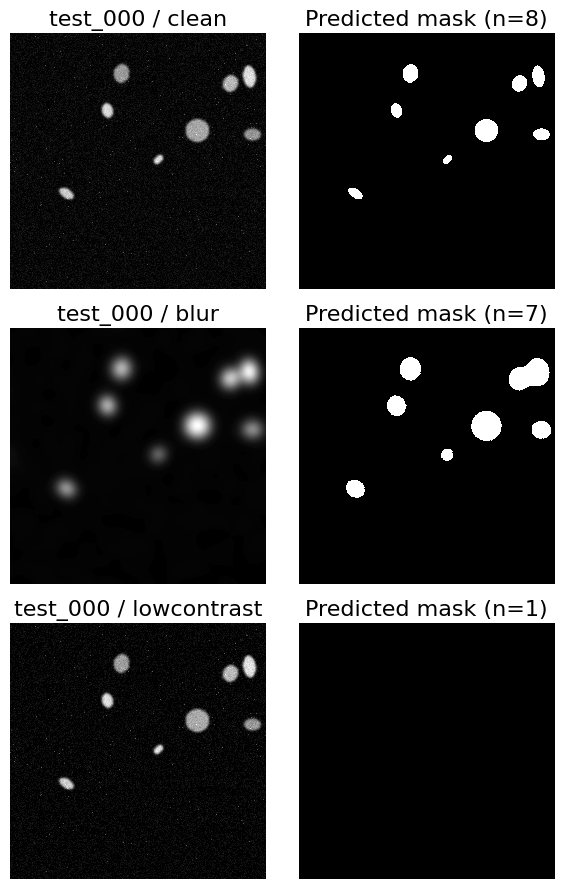

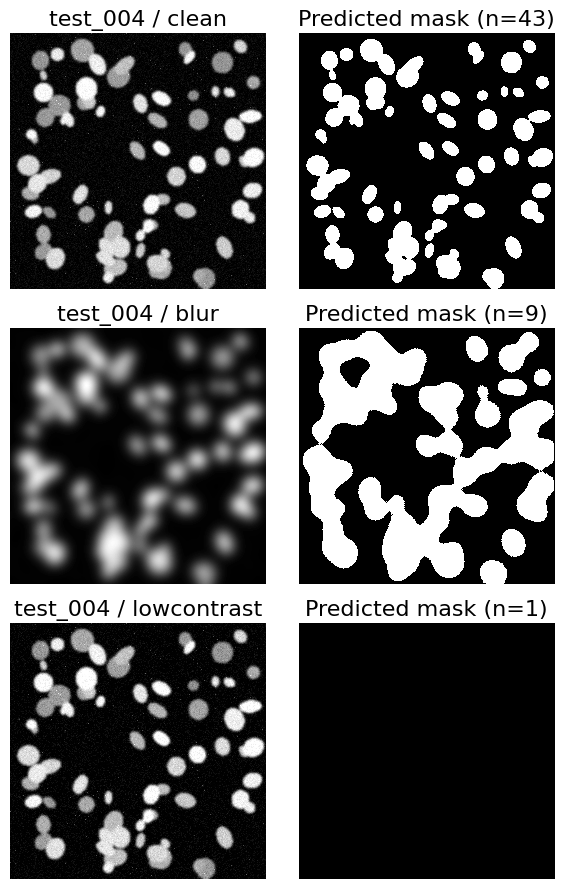

In [11]:
for base_id, variants in robustness_results.items():
    variant_names = list(variants.keys())
    fig, axes = plt.subplots(
        len(variant_names),
        2,
        figsize=(6, 3 * len(variant_names)),
    )

    if len(variant_names) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_index, variant in enumerate(variant_names):
        data = variants[variant]

        axes[row_index, 0].imshow(data["gray"], cmap="gray")
        axes[row_index, 0].set_title(f"{base_id} / {variant}", fontsize=16)
        axes[row_index, 0].axis("off")

        axes[row_index, 1].imshow(data["mask"], cmap="gray")
        axes[row_index, 1].set_title(
            f"Predicted mask (n={data['record']['n_objects']})",
            fontsize=16
        )
        axes[row_index, 1].axis("off")

    plt.tight_layout()
    fig.savefig(PROJECT_DIR / f"robustness_{base_id}.png", dpi=720, bbox_inches="tight")
    plt.show()

### **9. Quantify robustness**

Dice score or IoU close to 1 for the corrupted input implies that the predicted mask is similar to the one predicted for the original (uncorrupted) image.

A drop in this metric suggests that the model is sensitive to the corruption, even if the predicted mask still looks reasonable.

In [12]:
comparison_rows = []

for base_id, variants in robustness_results.items():
    clean = variants["clean"]

    for variant, data in variants.items():
        row = {
            "base_image": base_id,
            "variant": variant,
            "n_objects": data["record"]["n_objects"],
            "mean_area": data["record"]["mean_area"],
            "density_class": data["record"]["density_class"],
            "quality_flag": data["record"]["quality_flag"],
        }

        if variant == "clean":
            row["mask_dice_vs_clean"] = 1.0
            row["mask_iou_vs_clean"] = 1.0
            row["n_objects_delta"] = 0
        else:
            similarity = mask_similarity(
                data["mask"],
                clean["mask"],
            )
            row["mask_dice_vs_clean"] = round(similarity["dice"], 4)
            row["mask_iou_vs_clean"] = round(similarity["iou"], 4)
            row["n_objects_delta"] = (
                data["record"]["n_objects"]
                - clean["record"]["n_objects"]
            )

        comparison_rows.append(row)

robustness_df = pd.DataFrame(comparison_rows)
display(robustness_df)

,base_image,variant,n_objects,mean_area,density_class,quality_flag,mask_dice_vs_clean,mask_iou_vs_clean,n_objects_delta
0,test_000,clean,8,190.8,sparse,none,1.0000,1.0000,0
1,test_000,blur,7,426.6,sparse,none,0.6764,0.5111,-1
2,test_000,lowcontrast,1,65536.0,sparse,foreground occupies most of the image,0.0455,0.0233,-7
3,test_004,clean,43,328.3,clustered,none,1.0000,1.0000,0
4,test_004,blur,9,3091.7,sparse,none,0.6729,0.5070,-34
5,test_004,lowcontrast,1,65536.0,sparse,foreground occupies most of the image,0.3545,0.2154,-42


In [13]:
robustness_csv = PROJECT_DIR / "robustness_comparison.csv"
robustness_df.to_csv(robustness_csv, index=False)

print("Saved:", robustness_csv)

Saved: /content/drive/MyDrive/biomedical_image_project/robustness_comparison.csv


### **10. Final interpretation**

The hybrid pipeline clearly defines the responsibilities of separate components, and the results of this project demonstrate the effectiveness of this approach.

Firstly, the U-Net has completed its task of pixel-level segmentation with extraordinary precision, as demonstrated by the test Dice score of 0.9947. This score is almost 4 times better than what one could expect from the Otsu method (0.978-0.980 for the same images). Secondly, the connected components/simple regionprops pipeline has converted pixels into repeatable numerical values that serve as the basis for all further analysis. These values can be reproduced in any run of the pipeline, unlike the results of a language model. Thirdly, the deterministic rules written in Python have reliably categorized the results into different density levels and flagged outliers. On the set of 12 test images, not a single quality flag was raised, as expected.

Finally, the language model itself has converted numerical values into natural language descriptions without attempting any calculations. Notably, the model indicated one out of twelve test images (test_002 with the comment “analysis not perfect”) in the free-text replies. It might indicate that the model recognized some issues with the results, even if the deterministic rules had not been written yet. On the other hand, one cannot tell for sure whether the model was correct to flag those examples, as there is no reference dataset to which the model’s answers could be compared. The test described above demonstrates the reliability of the overall approach to image quality assessment.

The robustness analysis is partially positive as the described scheme appears to be generally reliable. The attempts to introduce errors resulted in detection of corrupted images at the stage of mask processing before proceeding to other stages. Specifically, blur decreased mask Dice scores by approximately 32-33%, ultimately reducing it to 67-68% when compared to the predictions on the non-corrupted images. Low contrast appeared to have a significantly more severe effect, although the decrease varied greatly between the test pictures, decreasing the score by 95% for test_000 and 65% for test_004. At the same time, the occurrence of such artifacts did not necessarily result in an alert being issued with the final JSON. The reason for this was that images with low contrast tended to transform into a single large regionoccupying the same area as the entire image, which was appropriately identified as an abnormality according to the rules. On the other hand, there was no such threshold for blurred images, which failed to trigger any alerts despite decreased Dice scores and fewer detected objects. This shows that the described pipeline is largely reliable but has one particular weakness.



### **Project conclusion**

As this project has come to an end, it becomes possible to reflect on the work ahead. One has seen how the process of turning raw biological images into numerical results works on a high level. Starting from raw microscopy scans, the project featured a standard computer vision pipeline that processed images in a step-by-step fashion.

**image validation** to **visual-language prompting** to **classical segmentation** to **learned segmentation** to **numerical object analysis** to **language-based interpretation** to **robustness evaluation**

Crucially, all steps had to be adjusted to ensure that the following stages would be able to utilize the preceding results. This project demonstrated that any computer vision task benefited from using the right tools for each level of analysis. The visual-language prompting paradigm (VLM) has proven to be a powerful tool for image-to-text tasks. Notably, the model demonstrated strong performance in producing consistent JSON-type outputs while managing to remain flexible for more free-text descriptions. However, it becomes unreliable when it comes to actual image analysis: In the test set, the vision-language model pointed out one image (in its open-ended comments), while the deterministic rules did not report any problems. This indicates that the model could be capturing additional qualities beyond the explicitly validated criteria, although this possibility cannot be confirmed due to the lack of a definitive quality control standard. The classical approach to segmentation (Ostu’s thresholding) has demonstrated consistent speed and transparency, bordering on the accuracy of more complex solutions like U-Net. However, it produces unreliable results when it comes to the density estimation, specifically the number of objects. Finally, the test had shown that the current ruleset, albeit reliable, was not foolproof, failing to catch a significant error in one of the artificially corrupted test images.

